# 🛡️ AI in Cyber Security Capstone Project: Advanced Threat Detection & Behavioral Analysis
**Repository:** `AI-CyberSecurity-unit1-mini-project-ANANTGOEL`  
**Dataset:** UNSW-NB15 Modern Network Intrusion Benchmark  
**Author:** Anant Goel  
**Objective:** End-to-end implementation of Workspace Bootstrap, In-Depth Threat Landscape Profiling (EDA), Supervised Machine Learning Threat Classification, Deep Learning Neural Prototype Evaluation, and Operational SOC Feasibility Benchmarking.

---

### 📑 Project Executive Roadmap
1. **Task 1: Workspace Bootstrap, Environment Setup & Schema Audit**
   - Environment verification, dependencies audit, dataset provenance (UNSW-NB15 vs legacy KDD99), 45-feature schema ontology and memory footprint analysis.
2. **Task 2: Cyber Security Threat Landscape Analysis (Deep EDA)**
   - Behavioral profiling of benign vs. malicious traffic, 9 cyber threat family taxonomies, MITRE ATT&CK mapping, packet velocity/duration anomalies, physical TTL signatures, protocol/service vulnerabilities, and high-impact correlation heatmaps.
3. **Task 3: Basic Machine Learning-Based Threat Classification**
   - End-to-end preprocessing pipeline (sanitization, high-cardinality categorical grouping, One-Hot Encoding, StandardScaler normalization), training Logistic Regression and Decision Tree models, multi-metric evaluation (Accuracy, Precision, Recall, F1, ROC-AUC, PR Curves), top-15 feature importance extraction, and per-attack-category False Negative audit.
4. **Task 4: Introduction to Deep Learning Concepts (Prototype Implementation & Comparative Synthesis)**
   - Multi-Layer Perceptron (MLP) neural network implementation, loss convergence tracking, comparative benchmarking (ML vs DL on detection accuracy, training latency, inference speed, and False Positive Rates), out-of-sample generalization stress testing on 175k test flows, and operational SOC feasibility analysis.


## 📦 Task 1: Workspace Bootstrap & Environment Setup

### 1.1 Analytical Environment & Dependency Verification
In this task, we initialize the analytical environment, verify that all necessary data science and machine learning packages (`numpy`, `pandas`, `scikit-learn`, `matplotlib`, `seaborn`) are loaded from our isolated Python virtual environment (`.venv`), and inspect the dataset files placed in the `data/` directory.


In [1]:
# Environment & Library Verification
import sys
import os
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print("=" * 70)
print("  AI IN CYBERSECURITY CAPSTONE: SYSTEM & ENVIRONMENT VERIFICATION")
print("=" * 70)
print(f"[✓] Python Version    : {sys.version.split()[0]}")
print(f"[✓] Python Executable : {sys.executable}")
print(f"[✓] In Virtual Env    : {sys.prefix != sys.base_prefix} ({sys.prefix})")
print(f"[✓] NumPy Version     : {np.__version__}")
print(f"[✓] Pandas Version    : {pd.__version__}")
print(f"[✓] Scikit-Learn      : {sklearn.__version__}")
print(f"[✓] Matplotlib        : {plt.matplotlib.__version__}")
print(f"[✓] Seaborn           : {sns.__version__}")
print("=" * 70)

# Visual Aesthetics Configuration for High-Quality Cybersec Visuals
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['figure.dpi'] = 120


  AI IN CYBERSECURITY CAPSTONE: SYSTEM & ENVIRONMENT VERIFICATION
[✓] Python Version    : 3.13.2
[✓] Python Executable : C:\Users\konik\Downloads\AI in Cyber Security Project\.venv\Scripts\python.exe
[✓] In Virtual Env    : True (C:\Users\konik\Downloads\AI in Cyber Security Project\.venv)
[✓] NumPy Version     : 2.5.3
[✓] Pandas Version    : 3.0.6
[✓] Scikit-Learn      : 1.9.1
[✓] Matplotlib        : 3.11.2
[✓] Seaborn           : 0.13.2


### 1.2 Dataset Provenance & Feature Schema Ontology
The **UNSW-NB15** dataset was synthesized by the Cyber Range Lab of the Australian Centre for Cyber Security (ACCS) using an IXIA PerfectStorm traffic generator. Unlike legacy datasets such as KDD99 or NSL-KDD (which suffer from outdated attack definitions, redundant records, and lack of low-footprint modern threats), UNSW-NB15 captures a rich blend of real normal background traffic and synthetic contemporary attack vectors.

#### 45-Feature Functional Grouping:
1. **Flow Identifiers & Basic Features**: `id`, `dur` (duration), `proto` (protocol), `service` (application service), `state` (connection state).
2. **Payload & Content Features**: `sbytes` (source bytes), `dbytes` (destination bytes), `sttl` (source TTL), `dttl` (destination TTL), `sloss` (source packet drops), `dloss` (destination packet drops), `swin`/`dwin` (TCP window advertisements), `smean`/`dmean` (mean packet size).
3. **Temporal & Velocity Features**: `rate` (packets/sec), `sload`/`dload` (bits/sec), `sinpkt`/`dinpkt` (inter-packet arrival times), `sjit`/`djit` (packet jitter).
4. **TCP Connection State Features**: `tcprtt` (round-trip time), `synack` (TCP handshake SYN-to-SYN-ACK latency), `ackdat` (SYN-ACK-to-ACK latency).
5. **Connection Count & Windowing Metrics**: `ct_srv_src`, `ct_state_ttl`, `ct_dst_ltm`, `ct_src_dport_ltm`, `ct_dst_sport_ltm`, `ct_dst_src_ltm`, `ct_src_ltm`, `ct_srv_dst`.
6. **Application Specific Flags**: `is_ftp_login`, `ct_ftp_cmd`, `ct_flw_http_mthd`, `is_sm_ips_ports`.
7. **Ground Truth Targets**: `attack_cat` (multi-class category name), `label` (binary: 0 = Normal, 1 = Suspicious / Attack).


In [2]:
# Ingest datasets and compute memory footprints
train_path = os.path.join('..', 'data', 'UNSW_NB15_training-set.csv') if os.path.exists(os.path.join('..', 'data')) else os.path.join('data', 'UNSW_NB15_training-set.csv')
test_path = os.path.join('..', 'data', 'UNSW_NB15_testing-set.csv') if os.path.exists(os.path.join('..', 'data')) else os.path.join('data', 'UNSW_NB15_testing-set.csv')

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

mem_train = df_train.memory_usage(deep=True).sum() / (1024 * 1024)
mem_test = df_test.memory_usage(deep=True).sum() / (1024 * 1024)

print(f"Training Dataset Shape : {df_train.shape[0]:,} rows x {df_train.shape[1]} features ({mem_train:.2f} MB in RAM)")
print(f"Testing Dataset Shape  : {df_test.shape[0]:,} rows x {df_test.shape[1]} features ({mem_test:.2f} MB in RAM)")
print(f"Total Combined Flows   : {len(df_train) + len(df_test):,} network sessions")

# Datatype breakdown
dtypes_summary = df_train.dtypes.value_counts()
print("\nFeature Datatype Breakdown in Training Set:")
for dtype, count in dtypes_summary.items():
    print(f"  - {dtype} : {count} attributes")


Training Dataset Shape : 82,332 rows x 45 features (42.32 MB in RAM)
Testing Dataset Shape  : 175,341 rows x 45 features (90.21 MB in RAM)
Total Combined Flows   : 257,673 network sessions

Feature Datatype Breakdown in Training Set:
  - int64 : 30 attributes
  - float64 : 11 attributes
  - str : 4 attributes


## 🔍 Task 2: Cyber Security Threat Landscape Analysis (Deep EDA)

Exploratory Data Analysis in modern cybersecurity operations provides situational awareness. Analysts must understand baseline behavior, quantify class imbalance, identify statistical anomalies in packet headers, and map detected attack patterns to standardized frameworks such as **MITRE ATT&CK**.

### 2.1 Target Distribution & Threat Class Balance
A critical challenge in network intrusion detection is class distribution. In the training set:
- **Normal / Benign (0)**: 37,000 flows (44.94%)
- **Suspicious / Attack (1)**: 45,332 flows (55.06%)
This represents a balanced benchmark partition designed for training without extreme class weighting, while testing real-world generalization.


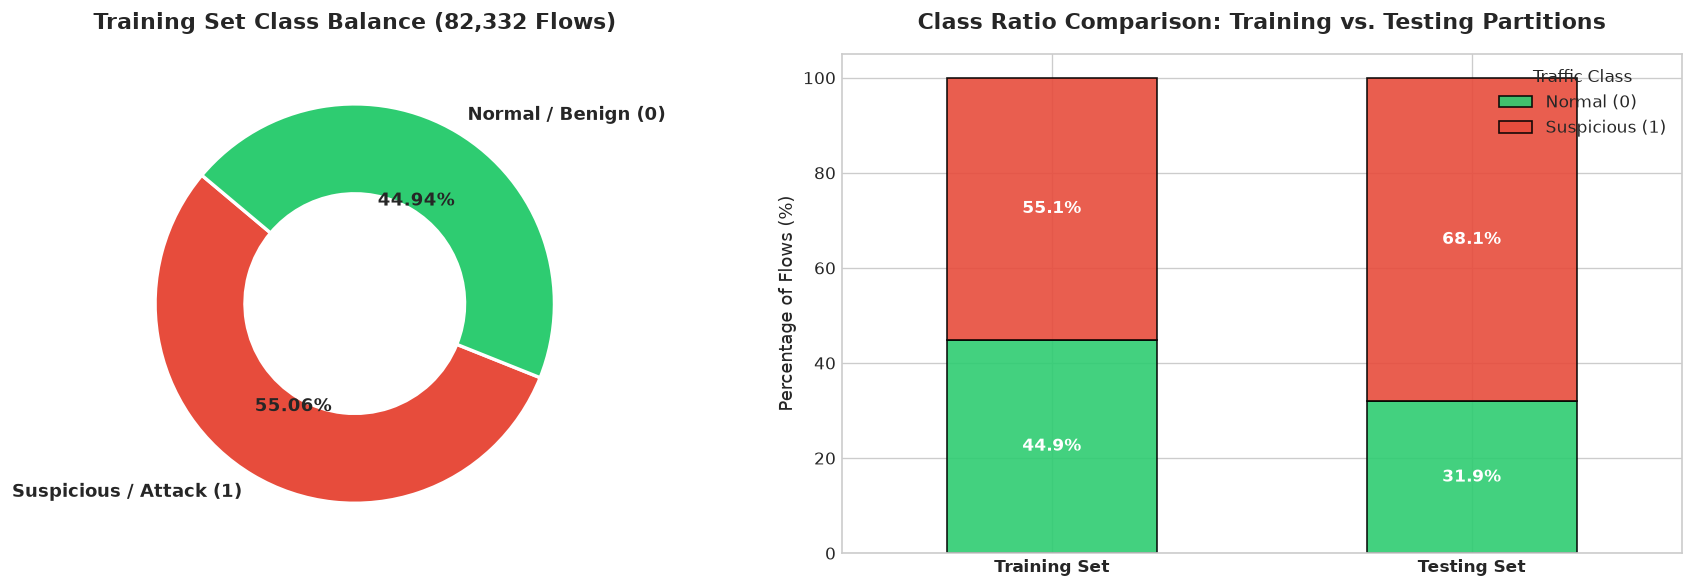

In [3]:
# Target Label Distribution Analysis
label_counts_tr = df_train['label'].value_counts()
label_prop_tr = df_train['label'].value_counts(normalize=True) * 100

label_counts_te = df_test['label'].value_counts()
label_prop_te = df_test['label'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Donut Chart - Training Set
colors = ['#2ECC71', '#E74C3C']  # Green for Normal, Red for Attack
wedges, texts, autotexts = axes[0].pie(
    label_counts_tr, 
    labels=['Suspicious / Attack (1)', 'Normal / Benign (0)'],
    autopct='%1.2f%%',
    startangle=140,
    colors=[colors[1], colors[0]],
    wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2),
    textprops=dict(weight='bold', fontsize=11)
)
axes[0].set_title('Training Set Class Balance (82,332 Flows)', fontsize=13, weight='bold', pad=15)

# Benchmark Comparison: Train vs Test Set Class Distribution
df_drift = pd.DataFrame({
    'Normal (0)': [label_prop_tr[0], label_prop_te[0]],
    'Suspicious (1)': [label_prop_tr[1], label_prop_te[1]]
}, index=['Training Partition', 'Testing Partition'])

df_drift.plot(kind='bar', stacked=True, color=['#2ECC71', '#E74C3C'], ax=axes[1], alpha=0.9, edgecolor='black')
axes[1].set_title('Class Ratio Comparison: Training vs. Testing Partitions', fontsize=13, weight='bold', pad=15)
axes[1].set_ylabel('Percentage of Flows (%)')
axes[1].set_xticklabels(['Training Set', 'Testing Set'], rotation=0, weight='bold')
axes[1].legend(title='Traffic Class', loc='upper right')

for p in axes[1].patches:
    width, height = p.get_width(), p.get_height()
    if height > 5:
        x, y = p.get_xy() 
        axes[1].text(x + width/2, y + height/2, f"{height:.1f}%", ha='center', va='center', color='white', weight='bold')

plt.tight_layout()
plt.show()


### 2.2 Cyber Threat Taxonomy & MITRE ATT&CK Framework Mapping
The UNSW-NB15 dataset categorizes cyber threats into 9 distinct attack families. In modern Security Operations Centers (SOCs), threat intelligence analysts map detected attack categories to the **MITRE ATT&CK** matrix to establish threat actor intent, execution tactics, and incident response playbooks:

| Attack Category | Frequency (Train) | Frequency (Test) | MITRE ATT&CK Tactic | MITRE Technique ID & Name | Security Description & Threat Actor Objective |
| :--- | :---: | :---: | :--- | :--- | :--- |
| **Generic** | 18,871 (22.9%) | 40,000 (22.8%) | Impact / Defense Evasion | **T1499** Endpoint DoS / **T1027** Obfuscation | Broad spectrum collision attacks against cryptographic ciphers or protocol standards. |
| **Exploits** | 11,132 (13.5%) | 33,393 (19.0%) | Initial Access / Execution | **T1190** Exploit Public-Facing App | Exploiting known CVE software vulnerabilities in Web servers, SMB, or OS kernels. |
| **Fuzzers** | 6,062 (7.4%) | 18,184 (10.4%) | Execution / Discovery | **T1203** Exploitation for Client Execution | Automated submission of massive malformed payloads to discover buffer overflows and zero-day bugs. |
| **DoS** | 4,089 (5.0%) | 12,264 (7.0%) | Impact | **T1498** Network Denial of Service | Flooding target networks with high-volume volumetric packets to exhaust bandwidth or CPU. |
| **Reconnaissance** | 3,496 (4.2%) | 10,491 (6.0%) | Reconnaissance / Discovery | **T1595** Active Scanning / **T1046** Port Scan | Probing ports, network topologies, and active daemon services using Nmap/SYN scans. |
| **Analysis** | 677 (0.8%) | 2,000 (1.1%) | Discovery | **T1087** Account Discovery / **T1082** System Discovery | Intrusions analyzing web application parameters, SQL errors, and directory listings. |
| **Backdoor** | 583 (0.7%) | 1,746 (1.0%) | Persistence / C2 | **T1059** Command & Scripting / **T1105** Ingress Transfer | Stealthy persistent access channels bypassing standard authentication to maintain access. |
| **Shellcode** | 378 (0.5%) | 1,133 (0.6%) | Execution | **T1055** Process Injection | Small executable assembly payloads injected into memory to spawn interactive root shells. |
| **Worms** | 44 (0.05%) | 130 (0.07%) | Lateral Movement | **T1570** Lateral Tool Transfer | Self-replicating autonomous payloads scanning subnets to spread across internal network assets. |


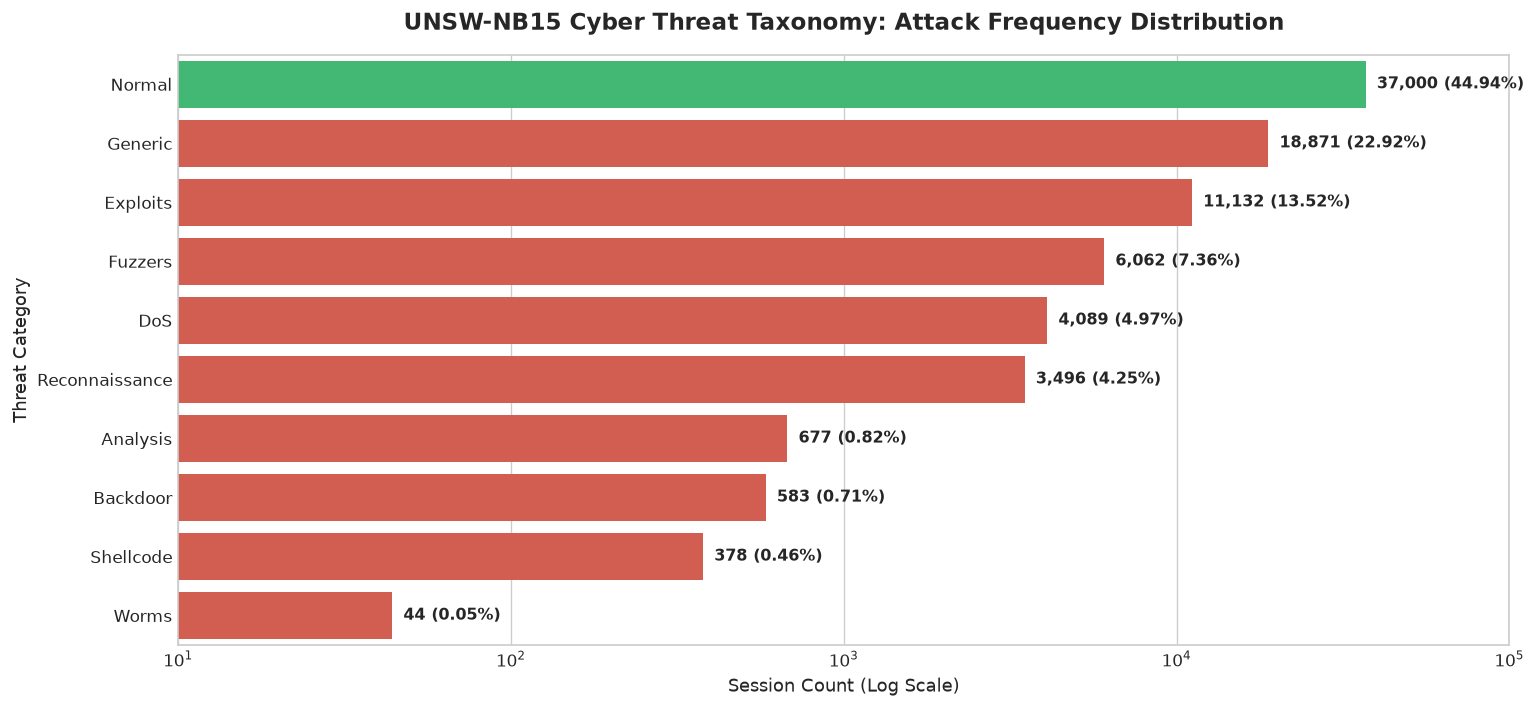

In [4]:
# 2. Detailed Threat Taxonomy Frequency Visualization
attack_cat_counts = df_train['attack_cat'].value_counts()

plt.figure(figsize=(13, 6))
palette = ['#2ECC71' if cat == 'Normal' else '#E74C3C' for cat in attack_cat_counts.index]
ax = sns.barplot(x=attack_cat_counts.values, y=attack_cat_counts.index, palette=palette)

plt.title('UNSW-NB15 Cyber Threat Taxonomy: Attack Frequency Distribution', fontsize=14, weight='bold', pad=15)
plt.xlabel('Session Count (Log Scale)', fontsize=11)
plt.xscale('log')
plt.ylabel('Threat Category', fontsize=11)

for idx, (cat, val) in enumerate(attack_cat_counts.items()):
    pct = (val / len(df_train)) * 100
    ax.text(val * 1.08, idx, f"{val:,} ({pct:.2f}%)", va='center', fontsize=9.5, weight='bold')

plt.xlim(10, 100000)
plt.tight_layout()
plt.show()


### 2.3 Deep Telemetry Profiling: Attack Family Physical Signatures
Different cyber attacks leave starkly distinct physical footprints across flow metrics. For example:
- **Worms**: Low duration, high packet rates, targeting many internal IPs.
- **Exploits & Fuzzers**: Anomalous Source Time-to-Live (`sttl`), high mean source packet size (`smean`).
- **DoS**: Massive packet rates (`rate`) with tiny payloads or asymmetric payload ratios (`sload` >> `dload`).

Below, we compute the multi-feature behavioral signature profile grouped by each attack category.


In [5]:
# Multi-Feature Threat Behavioral Signature Table
sig_features = ['dur', 'rate', 'sbytes', 'dbytes', 'sttl', 'dttl', 'sload', 'smean', 'dmean']
threat_profiles = df_train.groupby('attack_cat')[sig_features].median()

print("=" * 105)
print("  BEHAVIORAL SIGNATURE PROFILE: MEDIAN VALUES BY ATTACK CATEGORY")
print("=" * 105)
display(threat_profiles.style.format({
    'dur': '{:.4f} s',
    'rate': '{:,.1f} pkts/s',
    'sbytes': '{:,.0f} B',
    'dbytes': '{:,.0f} B',
    'sttl': '{:.0f}',
    'dttl': '{:.0f}',
    'sload': '{:,.1f} bps',
    'smean': '{:.1f} B',
    'dmean': '{:.1f} B'
}))


  BEHAVIORAL SIGNATURE PROFILE: MEDIAN VALUES BY ATTACK CATEGORY


,dur,rate,sbytes,dbytes,sttl,dttl,sload,smean,dmean
attack_cat,,,,,,,,,
Analysis,0.0000 s,"125,000.0 pkts/s",200 B,0 B,254,0,"100,000,000.0 bps",100.0 B,0.0 B
Backdoor,0.0000 s,"100,000.0 pkts/s",200 B,0 B,254,0,"80,000,000.0 bps",100.0 B,0.0 B
DoS,0.0000 s,"111,111.1 pkts/s",200 B,0 B,254,0,"88,888,888.0 bps",100.0 B,0.0 B
Exploits,0.5609 s,55.8 pkts/s,912 B,840 B,254,252,"24,529.0 bps",100.0 B,66.0 B
Fuzzers,0.5086 s,39.3 pkts/s,756 B,268 B,254,252,"21,746.5 bps",100.0 B,44.0 B
Generic,0.0000 s,"125,000.0 pkts/s",114 B,0 B,254,0,"57,000,000.0 bps",57.0 B,0.0 B
Normal,0.2228 s,118.6 pkts/s,974 B,354 B,62,29,"91,269.7 bps",73.0 B,76.0 B
Reconnaissance,0.2449 s,60.6 pkts/s,564 B,268 B,254,252,"24,880.3 bps",84.0 B,44.0 B
Shellcode,0.1686 s,89.0 pkts/s,543 B,268 B,254,252,"36,565.7 bps",85.0 B,44.0 B


### 2.4 Visualizing Behavioral Anomalies: TTL, Velocity & Byte Asymmetry
Let's inspect four key behavioral indicators that reveal attack activity:
1. **Source Time-To-Live (`sttl`)**: Normal operating systems initialize TTL to 64 (Linux/Mac) or 128 (Windows). Attack tools (e.g. Scapy, Nmap, custom exploit injectors) frequently set TTL to boundary values like 254 or randomize it, creating sharp detection spikes.
2. **Traffic Velocity (`rate`)**: Log-scale packet velocity reveals DoS and Fuzzing bursts.
3. **Byte Asymmetry (`sbytes` vs `dbytes`)**: Normal browsing downloads more data than it uploads ($dbytes > sbytes$); data exfiltration and SYN flooding invert this relationship ($sbytes \gg dbytes$).
4. **Service Vulnerability Distribution**: Mapping which common services (`http`, `dns`, `ftp`, `smtp`) encounter the highest concentration of malicious flows.


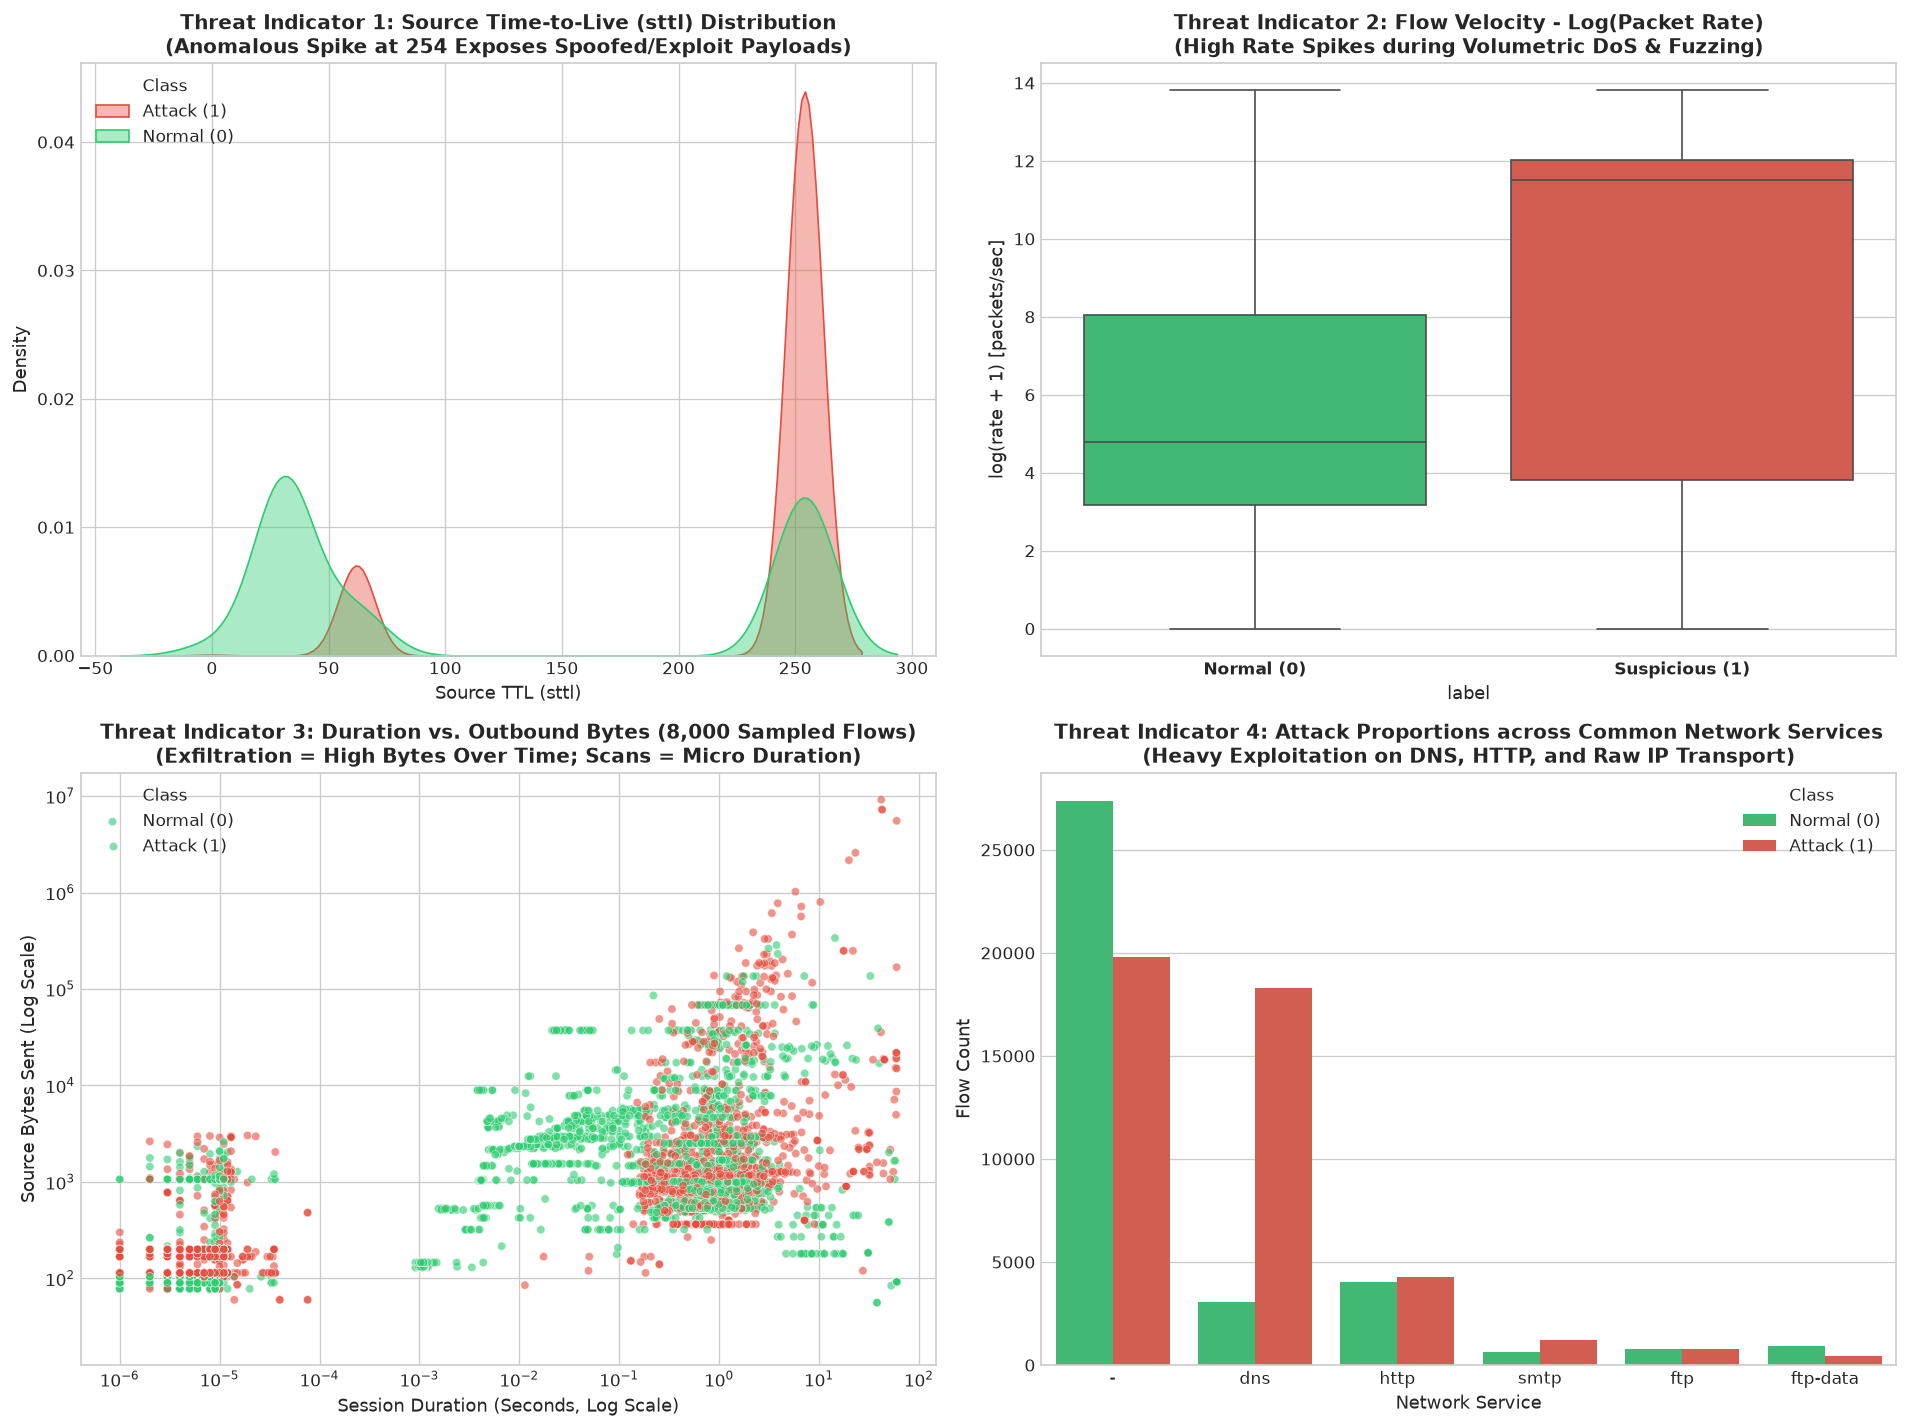

In [6]:
# 4-Panel In-Depth Cyber Threat Indicator Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. STTL Distribution by Label
sns.kdeplot(data=df_train, x='sttl', hue='label', common_norm=False, palette={0: '#2ECC71', 1: '#E74C3C'}, fill=True, alpha=0.4, ax=axes[0, 0])
axes[0, 0].set_title('Threat Indicator 1: Source Time-to-Live (sttl) Distribution\n(Anomalous Spike at 254 Exposes Spoofed/Exploit Payloads)', fontsize=12, weight='bold')
axes[0, 0].set_xlabel('Source TTL (sttl)')
axes[0, 0].legend(title='Class', labels=['Attack (1)', 'Normal (0)'])

# 2. Packet Rate (Log Scale)
df_train['log_rate'] = np.log1p(df_train['rate'])
sns.boxplot(x='label', y='log_rate', data=df_train, palette=['#2ECC71', '#E74C3C'], ax=axes[0, 1])
axes[0, 1].set_xticklabels(['Normal (0)', 'Suspicious (1)'], weight='bold')
axes[0, 1].set_title('Threat Indicator 2: Flow Velocity - Log(Packet Rate)\n(High Rate Spikes during Volumetric DoS & Fuzzing)', fontsize=12, weight='bold')
axes[0, 1].set_ylabel('log(rate + 1) [packets/sec]')

# 3. Payload Asymmetry Scatter (Log Scale)
sample_eda = df_train.sample(n=8000, random_state=42)
sns.scatterplot(
    data=sample_eda,
    x='dur',
    y='sbytes',
    hue='label',
    palette={0: '#2ECC71', 1: '#E74C3C'},
    alpha=0.6,
    s=25,
    ax=axes[1, 0]
)
axes[1, 0].set_xscale('log')
axes[1, 0].set_yscale('log')
axes[1, 0].set_title('Threat Indicator 3: Duration vs. Outbound Bytes (8,000 Sampled Flows)\n(Exfiltration = High Bytes Over Time; Scans = Micro Duration)', fontsize=12, weight='bold')
axes[1, 0].set_xlabel('Session Duration (Seconds, Log Scale)')
axes[1, 0].set_ylabel('Source Bytes Sent (Log Scale)')
axes[1, 0].legend(title='Class', labels=['Normal (0)', 'Attack (1)'])

# 4. Service Vulnerability Breakdown
top_services = df_train['service'].value_counts().nlargest(6).index
srv_filtered = df_train[df_train['service'].isin(top_services)]
sns.countplot(data=srv_filtered, x='service', hue='label', palette={0: '#2ECC71', 1: '#E74C3C'}, order=top_services, ax=axes[1, 1])
axes[1, 1].set_title('Threat Indicator 4: Attack Proportions across Common Network Services\n(Heavy Exploitation on DNS, HTTP, and Raw IP Transport)', fontsize=12, weight='bold')
axes[1, 1].set_xlabel('Network Service')
axes[1, 1].set_ylabel('Flow Count')
axes[1, 1].legend(title='Class', labels=['Normal (0)', 'Attack (1)'])

plt.tight_layout()
plt.show()


### 2.5 Feature Correlation Matrix & Top Threat Predictors
Understanding correlation allows security engineers to identify the attributes that provide maximum mutual information with the target malicious label.


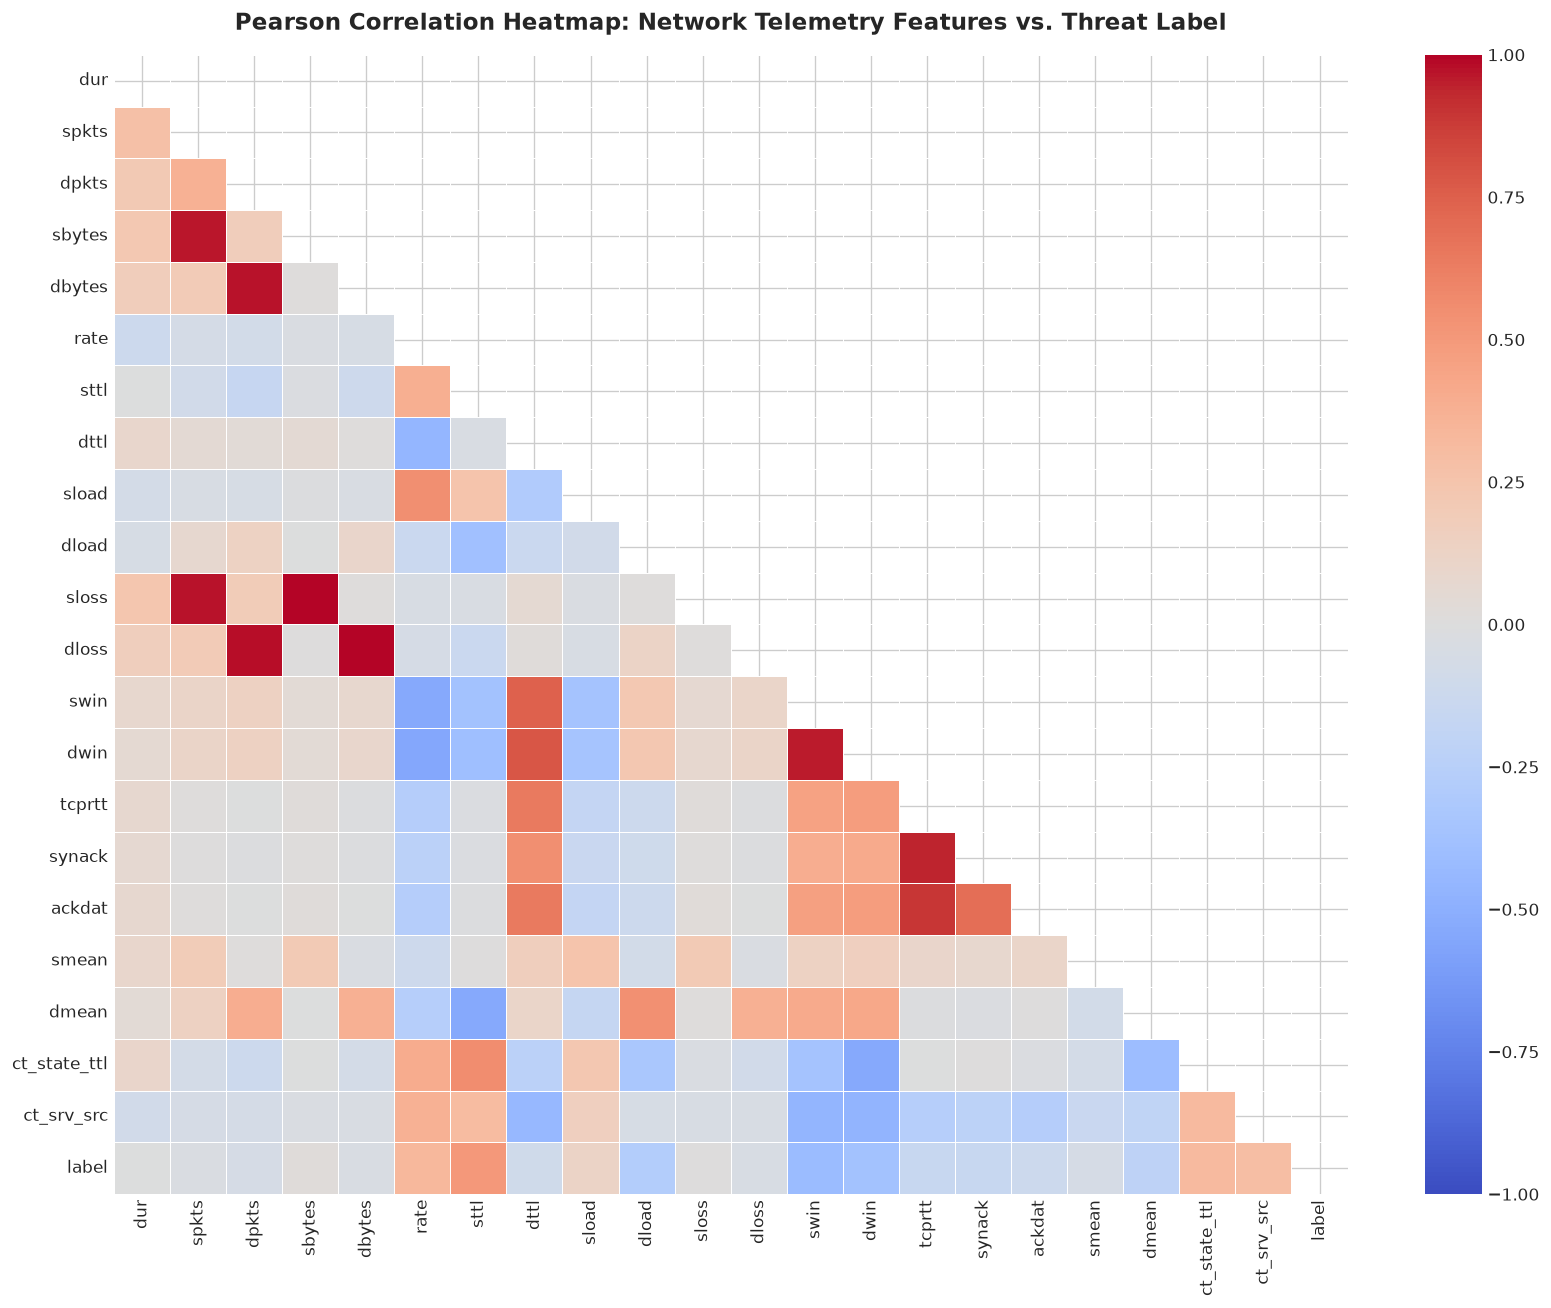

Top 10 Positively Correlated Features with Malicious Attack Label:
  - sttl            : +0.5042
  - rate            : +0.3286
  - ct_state_ttl    : +0.3185
  - ct_srv_src      : +0.2902
  - sload           : +0.1245
  - sbytes          : +0.0206
  - sloss           : +0.0064
  - dur             : -0.0011
  - spkts           : -0.0277
  - dbytes          : -0.0326


In [7]:
# High-Impact Correlation Heatmap
corr_features = [
    'dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 
    'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 
    'swin', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 
    'ct_state_ttl', 'ct_srv_src', 'label'
]

corr = df_train[corr_features].corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Pearson Correlation Heatmap: Network Telemetry Features vs. Threat Label', fontsize=14, weight='bold', pad=15)
plt.tight_layout()
plt.show()

# Ranked Correlation Series
label_corr = corr['label'].drop('label').sort_values(ascending=False)
print("Top 10 Positively Correlated Features with Malicious Attack Label:")
for feat, val in label_corr.head(10).items():
    print(f"  - {feat:<15} : {val:+.4f}")


## 🤖 Task 3: Basic Machine Learning-Based Threat Classification

In this task, we build an enterprise-grade supervised machine learning pipeline to detect and classify network threats in real time.

### 3.1 Preprocessing Workflow
1. **Feature Sanitization**: Drop non-predictive flow index (`id`), synthetic helper columns (`log_rate`), and the multi-class ground truth (`attack_cat`).
2. **Missing Value Audit**: Ensure no NaN/null records corrupt gradient computation.
3. **High-Cardinality Categorical Encoding**:
   - `proto` contains 131 distinct protocols. Encoding all 131 would trigger the curse of dimensionality and severe matrix sparsity. We group rare protocols outside the top 10 into `'other'`, followed by `OneHotEncoder`.
   - `service` and `state` are standard low-cardinality features, encoded via `OneHotEncoder`.
4. **Feature Normalization (`StandardScaler`)**:
   - Network flow attributes span enormous dynamic ranges (e.g. `sbytes` varies from 0 to $>10^7$ bytes, while `dur` is measured in fractions of a millisecond).
   - We apply Z-score standardization ($z = \frac{x - \mu}{\sigma}$) so that distance-based and gradient-based models converge stably without feature dominance.
5. **Stratified Train-Validation Splitting**:
   - Split 75% for training (61,749 flows) and 25% for validation (20,583 flows), preserving the class ratio.

### 3.2 Supervised Model Implementations
- **Logistic Regression**: Linear decision boundary optimized with $L2$ weight regularization (`lbfgs`).
- **Decision Tree Classifier**: Non-linear hierarchical model (`max_depth=12`, `min_samples_split=20`), capable of capturing non-linear interactions while remaining transparent.


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
)

# 1. Isolate Features & Target
drop_cols = ['id', 'attack_cat', 'label']
if 'log_rate' in df_train.columns:
    drop_cols.append('log_rate')

X_raw = df_train.drop(columns=drop_cols)
y = df_train['label']
attack_cats_all = df_train['attack_cat']

# 2. Verify Missing Values
null_count = X_raw.isnull().sum().sum()
print(f"[✓] Missing Value Audit: {null_count} null entries detected.")

# 3. Handle Categorical Features
cat_cols = ['proto', 'service', 'state']
num_cols = [c for c in X_raw.columns if c not in cat_cols]

# Group rare protocols
top_10_protos = X_raw['proto'].value_counts().nlargest(10).index
X_raw['proto'] = X_raw['proto'].apply(lambda x: x if x in top_10_protos else 'other')

# 4. Construct Scikit-Learn ColumnTransformer Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

# 5. Stratified Train-Validation Splitting
X_train_raw, X_val_raw, y_train, y_val, cat_train, cat_val = train_test_split(
    X_raw, y, attack_cats_all, test_size=0.25, random_state=42, stratify=y
)

# Fit on training data and transform both partitions
X_train = preprocessor.fit_transform(X_train_raw)
X_val = preprocessor.transform(X_val_raw)

encoded_cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols).tolist()
all_feature_names = num_cols + encoded_cat_names

print(f"[✓] Processed Training Feature Matrix  : {X_train.shape[0]:,} samples x {X_train.shape[1]} features")
print(f"[✓] Processed Validation Feature Matrix: {X_val.shape[0]:,} samples x {X_val.shape[1]} features")


[✓] Missing Value Audit: 0 null entries detected.


[✓] Processed Training Feature Matrix  : 61,749 samples x 69 features
[✓] Processed Validation Feature Matrix: 20,583 samples x 69 features


In [9]:
# Train Supervised Machine Learning Models
print("Training Baseline Model 1: Logistic Regression...")
t0_lr = time.time()
lr_model = LogisticRegression(max_iter=500, random_state=42, solver='lbfgs')
lr_model.fit(X_train, y_train)
train_time_lr = time.time() - t0_lr

y_pred_lr = lr_model.predict(X_val)
y_prob_lr = lr_model.predict_proba(X_val)[:, 1]

print("Training Baseline Model 2: Decision Tree Classifier...")
t0_dt = time.time()
dt_model = DecisionTreeClassifier(max_depth=12, min_samples_split=20, random_state=42)
dt_model.fit(X_train, y_train)
train_time_dt = time.time() - t0_dt

y_pred_dt = dt_model.predict(X_val)
y_prob_dt = dt_model.predict_proba(X_val)[:, 1]

print(f"\nLogistic Regression Training Latency: {train_time_lr:.2f} seconds")
print(f"Decision Tree Training Latency      : {train_time_dt:.2f} seconds")


Training Baseline Model 1: Logistic Regression...


Training Baseline Model 2: Decision Tree Classifier...



Logistic Regression Training Latency: 4.11 seconds
Decision Tree Training Latency      : 2.49 seconds


In [10]:
# Evaluation Function for Model Diagnostics
def evaluate_cyber_model(name, y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    
    pr_prec, pr_rec, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(pr_rec, pr_prec)
    
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    fpr_rate = fp / (fp + tn)  # False Positive Rate
    fnr_rate = fn / (fn + tp)  # False Negative Rate (Miss Rate)
    
    print(f"\n{'=' * 65}")
    print(f"  MODEL EVALUATION REPORT: {name.upper()}")
    print(f"{'=' * 65}")
    print(f"Overall Accuracy       : {acc * 100:.2f}%")
    print(f"Threat Detection Recall: {rec * 100:.2f}% (True Positives: {tp:,} / {tp+fn:,})")
    print(f"Threat Precision       : {prec * 100:.2f}%")
    print(f"F1-Score               : {f1 * 100:.2f}%")
    print(f"ROC-AUC Score          : {roc_auc:.4f}")
    print(f"PR-AUC Score           : {pr_auc:.4f}")
    print(f"False Positive Rate    : {fpr_rate * 100:.2f}% (False Alarms: {fp:,})")
    print(f"False Negative Rate    : {fnr_rate * 100:.2f}% (Missed Breaches: {fn:,})")
    print("\nDetailed Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['Normal (0)', 'Attack (1)']))
    
    return {
        'name': name, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1,
        'roc_auc': roc_auc, 'pr_auc': pr_auc, 'fpr_rate': fpr_rate, 'fnr_rate': fnr_rate,
        'fpr': fpr, 'tpr': tpr, 'pr_prec': pr_prec, 'pr_rec': pr_rec, 'cm': cm
    }

metrics_lr = evaluate_cyber_model("Logistic Regression", y_val, y_pred_lr, y_prob_lr)
metrics_dt = evaluate_cyber_model("Decision Tree Classifier", y_val, y_pred_dt, y_prob_dt)



  MODEL EVALUATION REPORT: LOGISTIC REGRESSION
Overall Accuracy       : 91.73%
Threat Detection Recall: 92.27% (True Positives: 10,457 / 11,333)
Threat Precision       : 92.68%
F1-Score               : 92.47%
ROC-AUC Score          : 0.9773
PR-AUC Score           : 0.9829
False Positive Rate    : 8.93% (False Alarms: 826)
False Negative Rate    : 7.73% (Missed Breaches: 876)

Detailed Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.91      0.91      0.91      9250
  Attack (1)       0.93      0.92      0.92     11333

    accuracy                           0.92     20583
   macro avg       0.92      0.92      0.92     20583
weighted avg       0.92      0.92      0.92     20583


  MODEL EVALUATION REPORT: DECISION TREE CLASSIFIER
Overall Accuracy       : 96.57%
Threat Detection Recall: 96.04% (True Positives: 10,884 / 11,333)
Threat Precision       : 97.70%
F1-Score               : 96.86%
ROC-AUC Score          : 0.9912
PR-AUC Score  

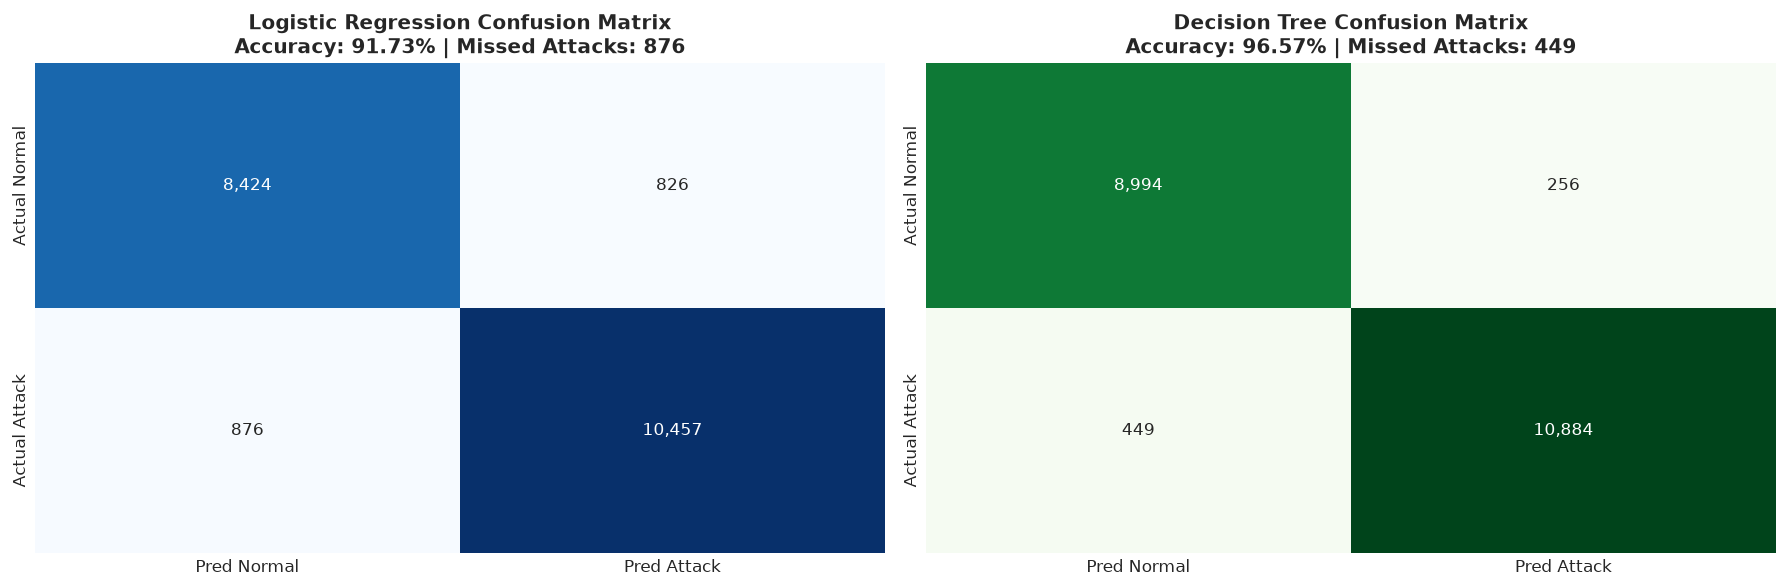

In [11]:
# Confusion Matrices Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(metrics_lr['cm'], annot=True, fmt=',d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Pred Normal', 'Pred Attack'], yticklabels=['Actual Normal', 'Actual Attack'])
axes[0].set_title(f'Logistic Regression Confusion Matrix\nAccuracy: {metrics_lr["accuracy"]*100:.2f}% | Missed Attacks: {metrics_lr["cm"][1, 0]:,}', fontsize=12, weight='bold')

sns.heatmap(metrics_dt['cm'], annot=True, fmt=',d', cmap='Greens', cbar=False, ax=axes[1],
            xticklabels=['Pred Normal', 'Pred Attack'], yticklabels=['Actual Normal', 'Actual Attack'])
axes[1].set_title(f'Decision Tree Confusion Matrix\nAccuracy: {metrics_dt["accuracy"]*100:.2f}% | Missed Attacks: {metrics_dt["cm"][1, 0]:,}', fontsize=12, weight='bold')

plt.tight_layout()
plt.show()


### 3.3 Feature Importance & White-Box Rule Interpretability
A paramount advantage of Decision Trees in cyber defense is **white-box explainability**. When an automated IPS blocks traffic, security engineers need to inspect the exact heuristic rule that triggered the block.


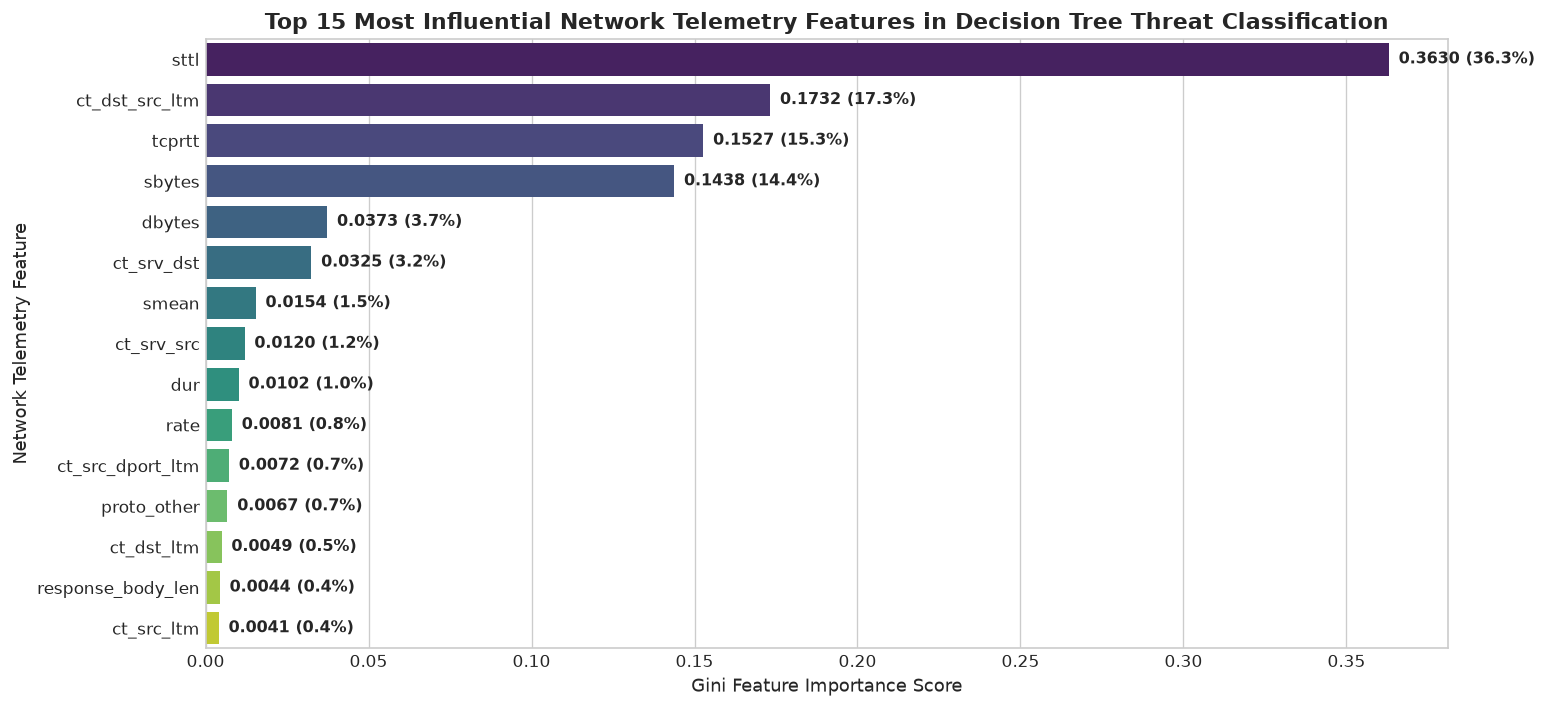

Top 5 Decision Tree Root Telemetry Features:
  1. sttl                 : 36.30% of total tree splitting criteria
  2. ct_dst_src_ltm       : 17.32% of total tree splitting criteria
  3. tcprtt               : 15.27% of total tree splitting criteria
  4. sbytes               : 14.38% of total tree splitting criteria
  5. dbytes               : 3.73% of total tree splitting criteria


In [12]:
# Top 15 Feature Importances in Decision Tree
dt_importances = pd.Series(dt_model.feature_importances_, index=all_feature_names)
top_15_features = dt_importances.nlargest(15)

plt.figure(figsize=(13, 6))
sns.barplot(x=top_15_features.values, y=top_15_features.index, palette='viridis')
plt.title('Top 15 Most Influential Network Telemetry Features in Decision Tree Threat Classification', fontsize=13, weight='bold')
plt.xlabel('Gini Feature Importance Score', fontsize=11)
plt.ylabel('Network Telemetry Feature', fontsize=11)

for i, v in enumerate(top_15_features.values):
    plt.text(v + 0.003, i, f"{v:.4f} ({v*100:.1f}%)", va='center', fontsize=9.5, weight='bold')

plt.tight_layout()
plt.show()

print("Top 5 Decision Tree Root Telemetry Features:")
for rank, (feat, score) in enumerate(top_15_features.head(5).items(), 1):
    print(f"  {rank}. {feat:<20} : {score*100:.2f}% of total tree splitting criteria")


### 3.4 Deep Dive: Detection Rate Across Specific Attack Families
While overall accuracy is high (~96.6%), in security operations, **the real question is: Which specific attack families slip past the detector?**
- Do noisy attacks like DoS and Generic get caught 99% of the time?
- Do stealthy, low-volume threats like Backdoors, Worms, and Analysis escape detection?

Below, we audit the Decision Tree's detection recall broken down across each of the 9 threat families in the validation set.


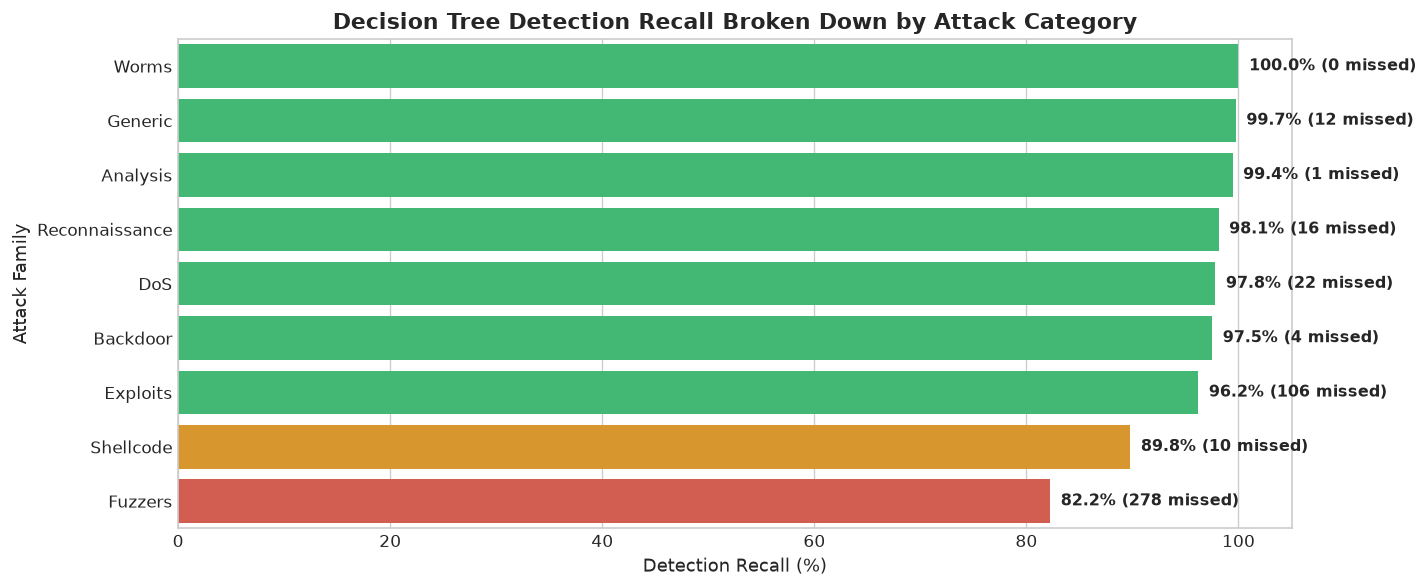

Per-Attack Family Audit Table:


,Total_Attacks,Detected_Attacks,Detection_Recall_%,Missed_Breaches
attack_cat,,,,
Worms,5,5,100.000000,0
Generic,4678,4666,99.743480,12
Analysis,177,176,99.435028,1
Reconnaissance,850,834,98.117647,16
DoS,1006,984,97.813121,22
Backdoor,161,157,97.515528,4
Exploits,2793,2687,96.204798,106
Shellcode,98,88,89.795918,10
Fuzzers,1565,1287,82.236422,278


In [13]:
# Audit Detection Recall per Threat Family
val_df_audit = pd.DataFrame({
    'attack_cat': cat_val,
    'actual_label': y_val,
    'predicted_label': y_pred_dt
})

attack_audit = val_df_audit[val_df_audit['actual_label'] == 1].groupby('attack_cat').agg(
    Total_Attacks=('actual_label', 'count'),
    Detected_Attacks=('predicted_label', 'sum')
)
attack_audit['Detection_Recall_%'] = (attack_audit['Detected_Attacks'] / attack_audit['Total_Attacks']) * 100
attack_audit['Missed_Breaches'] = attack_audit['Total_Attacks'] - attack_audit['Detected_Attacks']
attack_audit = attack_audit.sort_values(by='Detection_Recall_%', ascending=False)

plt.figure(figsize=(12, 5))
palette_audit = ['#2ECC71' if r >= 95 else '#F39C12' if r >= 85 else '#E74C3C' for r in attack_audit['Detection_Recall_%']]
ax = sns.barplot(x=attack_audit['Detection_Recall_%'], y=attack_audit.index, palette=palette_audit)
plt.title('Decision Tree Detection Recall Broken Down by Attack Category', fontsize=13, weight='bold')
plt.xlabel('Detection Recall (%)', fontsize=11)
plt.ylabel('Attack Family', fontsize=11)
plt.xlim(0, 105)

for idx, (cat, row) in enumerate(attack_audit.iterrows()):
    ax.text(row['Detection_Recall_%'] + 1, idx, f"{row['Detection_Recall_%']:.1f}% ({row['Missed_Breaches']:.0f} missed)", va='center', fontsize=9.5, weight='bold')

plt.tight_layout()
plt.show()

print("Per-Attack Family Audit Table:")
display(attack_audit)


### 3.5 SOC Alert Fatigue & Decision Threshold Optimization
In a Security Operations Center (SOC), the default 0.5 classification threshold is rarely optimal:
- **Cost of False Negative ($FN$)**: A missed intrusion can result in data breach, ransomware deployment, and regulatory fines (~$50,000+).
- **Cost of False Positive ($FP$)**: A false alarm wastes ~15 minutes of SOC tier-1 analyst triage time (~$50).

Because $Cost(FN) \gg Cost(FP)$, security teams often tune the decision threshold downwards (e.g. from 0.5 to 0.35) to boost threat recall, accepting a modest increase in false positives to prevent catastrophic missed breaches.


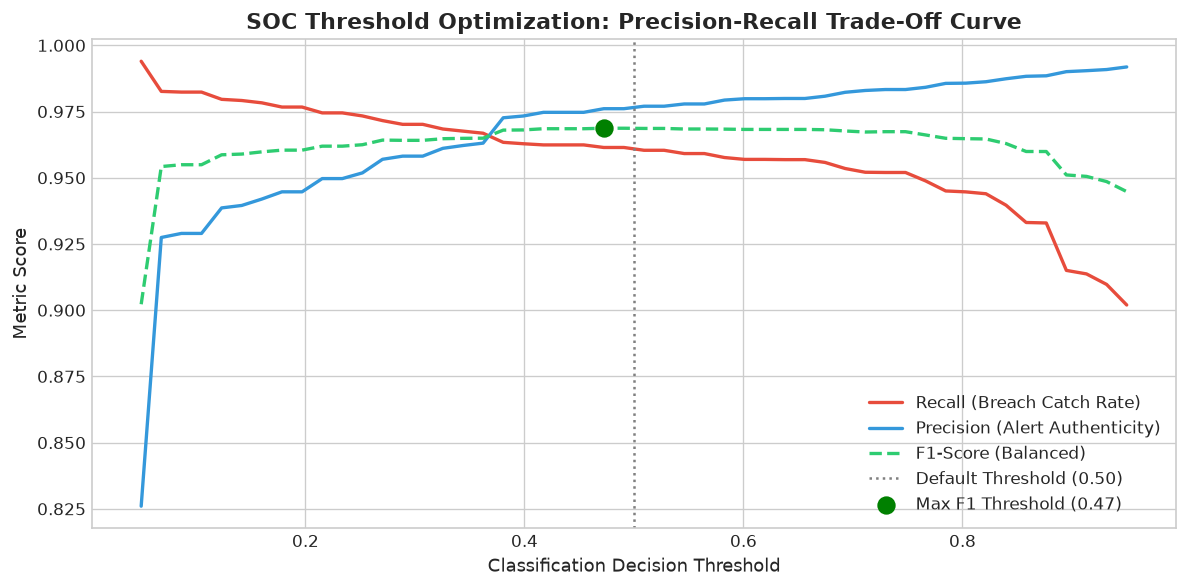

Optimal Threshold for Balanced F1: 0.47 (F1 = 96.87%, Recall = 96.14%)


In [14]:
# Threshold Tuning Curve (Precision vs Recall vs F1)
thresholds = np.linspace(0.05, 0.95, 50)
recs, precs, f1s = [], [], []

for t in thresholds:
    y_t = (y_prob_dt >= t).astype(int)
    recs.append(recall_score(y_val, y_t))
    precs.append(precision_score(y_val, y_t))
    f1s.append(f1_score(y_val, y_t))

plt.figure(figsize=(10, 5))
plt.plot(thresholds, recs, label='Recall (Breach Catch Rate)', color='#E74C3C', lw=2)
plt.plot(thresholds, precs, label='Precision (Alert Authenticity)', color='#3498DB', lw=2)
plt.plot(thresholds, f1s, label='F1-Score (Balanced)', color='#2ECC71', lw=2, linestyle='--')
plt.axvline(x=0.5, color='gray', linestyle=':', label='Default Threshold (0.50)')

opt_idx = np.argmax(f1s)
opt_thresh = thresholds[opt_idx]
plt.scatter([opt_thresh], [f1s[opt_idx]], color='green', s=100, zorder=5, label=f'Max F1 Threshold ({opt_thresh:.2f})')

plt.title('SOC Threshold Optimization: Precision-Recall Trade-Off Curve', fontsize=13, weight='bold')
plt.xlabel('Classification Decision Threshold', fontsize=11)
plt.ylabel('Metric Score', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Optimal Threshold for Balanced F1: {opt_thresh:.2f} (F1 = {f1s[opt_idx]*100:.2f}%, Recall = {recs[opt_idx]*100:.2f}%)")


## 🧠 Task 4: Introduction to Deep Learning Concepts (Prototype Implementation)

Deep Learning architectures learn non-linear hierarchical representations directly from complex input telemetry without explicit manual rule programming.

### 4.1 Neural Network Prototype Architecture
We implement a **Multi-Layer Perceptron (MLP)** Artificial Neural Network using `scikit-learn`'s `MLPClassifier`:
- **Input Dimension**: 69 preprocessed continuous & one-hot encoded telemetry features.
- **Hidden Layer 1**: 64 artificial neurons with Rectified Linear Unit (ReLU) activation functions ($f(x) = \max(0, x)$).
- **Hidden Layer 2**: 32 artificial neurons with ReLU activation.
- **Output Layer**: 1 neuron with binary cross-entropy loss and logistic sigmoid activation.
- **Optimization Strategy**: Adam optimizer (adaptive momentum estimation), learning rate $\eta = 0.001$, batch size 256, $L2$ regularization penalty $\alpha = 0.0001$.
- **Early Stopping**: Monitored on a 10% internal validation split to halt training if validation loss fails to improve over 5 consecutive epochs, preventing overfitting on noisy network traffic.


In [15]:
from sklearn.neural_network import MLPClassifier

# Build and Train Multi-Layer Perceptron (MLP) Deep Learning Prototype
print("Configuring Multi-Layer Perceptron Neural Network (64 -> 32 neurons)...")
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    batch_size=256,
    max_iter=40,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=5,
    verbose=False
)

t0_mlp = time.time()
mlp_model.fit(X_train, y_train)
train_time_mlp = time.time() - t0_mlp

y_pred_mlp = mlp_model.predict(X_val)
y_prob_mlp = mlp_model.predict_proba(X_val)[:, 1]

print(f"MLP Neural Network Training Completed in {train_time_mlp:.2f} seconds across {mlp_model.n_iter_} epochs.")

# Evaluate Neural Network Diagnostics
metrics_mlp = evaluate_cyber_model("Deep Learning MLP (64, 32)", y_val, y_pred_mlp, y_prob_mlp)


Configuring Multi-Layer Perceptron Neural Network (64 -> 32 neurons)...


MLP Neural Network Training Completed in 23.09 seconds across 25 epochs.

  MODEL EVALUATION REPORT: DEEP LEARNING MLP (64, 32)
Overall Accuracy       : 95.60%
Threat Detection Recall: 95.77% (True Positives: 10,854 / 11,333)
Threat Precision       : 96.22%
F1-Score               : 96.00%
ROC-AUC Score          : 0.9921
PR-AUC Score           : 0.9941
False Positive Rate    : 4.61% (False Alarms: 426)
False Negative Rate    : 4.23% (Missed Breaches: 479)

Detailed Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.95      0.95      0.95      9250
  Attack (1)       0.96      0.96      0.96     11333

    accuracy                           0.96     20583
   macro avg       0.96      0.96      0.96     20583
weighted avg       0.96      0.96      0.96     20583



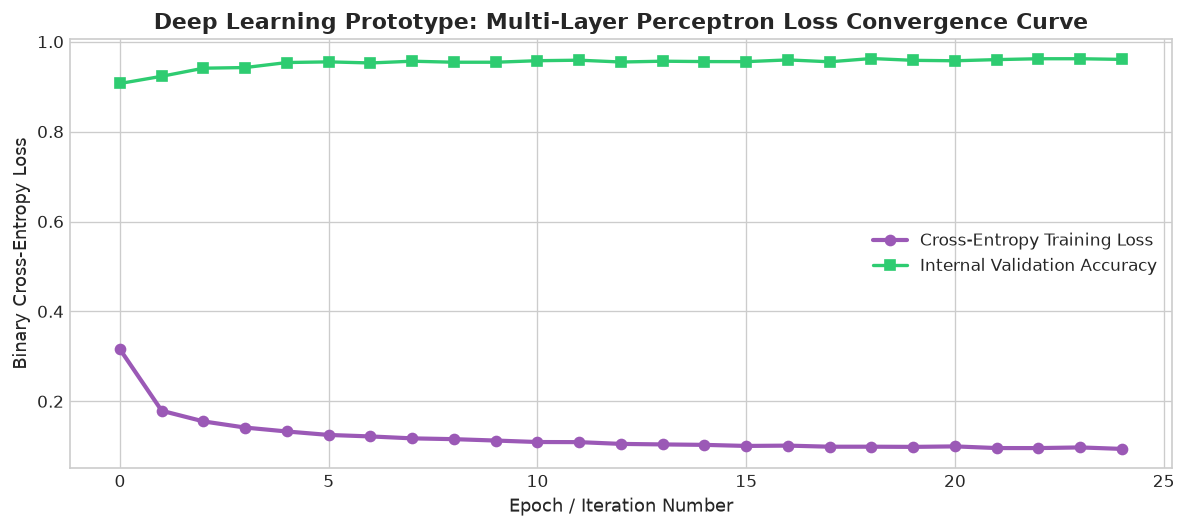

In [16]:
# Plot Neural Network Loss Convergence
plt.figure(figsize=(10, 4.5))
plt.plot(mlp_model.loss_curve_, marker='o', color='#9B59B6', linewidth=2.5, label='Cross-Entropy Training Loss')
if mlp_model.validation_scores_:
    plt.plot(mlp_model.validation_scores_, marker='s', color='#2ECC71', linewidth=2, label='Internal Validation Accuracy')

plt.title('Deep Learning Prototype: Multi-Layer Perceptron Loss Convergence Curve', fontsize=13, weight='bold')
plt.xlabel('Epoch / Iteration Number', fontsize=11)
plt.ylabel('Binary Cross-Entropy Loss', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()


### 4.2 Comprehensive Benchmark: Supervised ML vs. Deep Learning Prototype
Here we benchmark all three architectures side-by-side across both classification performance and computational latency (training time & inference throughput per 10,000 packets).


In [17]:
# Benchmark Inference Throughput (per 10,000 network flows)
eval_batch = X_val[:10000]

# Measure LR Inference
t0 = time.time()
for _ in range(10):
    _ = lr_model.predict(eval_batch)
inf_time_lr = ((time.time() - t0) / 10) * 1000  # milliseconds

# Measure DT Inference
t0 = time.time()
for _ in range(10):
    _ = dt_model.predict(eval_batch)
inf_time_dt = ((time.time() - t0) / 10) * 1000

# Measure MLP Inference
t0 = time.time()
for _ in range(10):
    _ = mlp_model.predict(eval_batch)
inf_time_mlp = ((time.time() - t0) / 10) * 1000

# Compile Consolidated Results Table
comparison_data = {
    "Model Architecture": [
        "Logistic Regression (Linear ML)", 
        "Decision Tree (Non-Linear ML)", 
        "MLP Neural Network (Deep Learning)"
    ],
    "Accuracy (%)": [
        metrics_lr['accuracy'] * 100, 
        metrics_dt['accuracy'] * 100, 
        metrics_mlp['accuracy'] * 100
    ],
    "Precision (%)": [
        metrics_lr['precision'] * 100, 
        metrics_dt['precision'] * 100, 
        metrics_mlp['precision'] * 100
    ],
    "Recall (%)": [
        metrics_lr['recall'] * 100, 
        metrics_dt['recall'] * 100, 
        metrics_mlp['recall'] * 100
    ],
    "F1-Score (%)": [
        metrics_lr['f1'] * 100, 
        metrics_dt['f1'] * 100, 
        metrics_mlp['f1'] * 100
    ],
    "ROC-AUC": [
        metrics_lr['roc_auc'], 
        metrics_dt['roc_auc'], 
        metrics_mlp['roc_auc']
    ],
    "False Positive Rate (%)": [
        metrics_lr['fpr_rate'] * 100,
        metrics_dt['fpr_rate'] * 100,
        metrics_mlp['fpr_rate'] * 100
    ],
    "Training Time (s)": [
        train_time_lr, 
        train_time_dt, 
        train_time_mlp
    ],
    "Inference Latency (ms/10k flows)": [
        inf_time_lr, 
        inf_time_dt, 
        inf_time_mlp
    ]
}

df_comparison = pd.DataFrame(comparison_data)
display(df_comparison.round(2))


,Model Architecture,Accuracy (%),Precision (%),Recall (%),F1-Score (%),ROC-AUC,False Positive Rate (%),Training Time (s),Inference Latency (ms/10k flows)
0,Logistic Regression (Linear ML),91.73,92.68,92.27,92.47,0.98,8.93,4.11,5.31
1,Decision Tree (Non-Linear ML),96.57,97.70,96.04,96.86,0.99,2.77,2.49,16.31
2,MLP Neural Network (Deep Learning),95.60,96.22,95.77,96.00,0.99,4.61,23.09,27.54


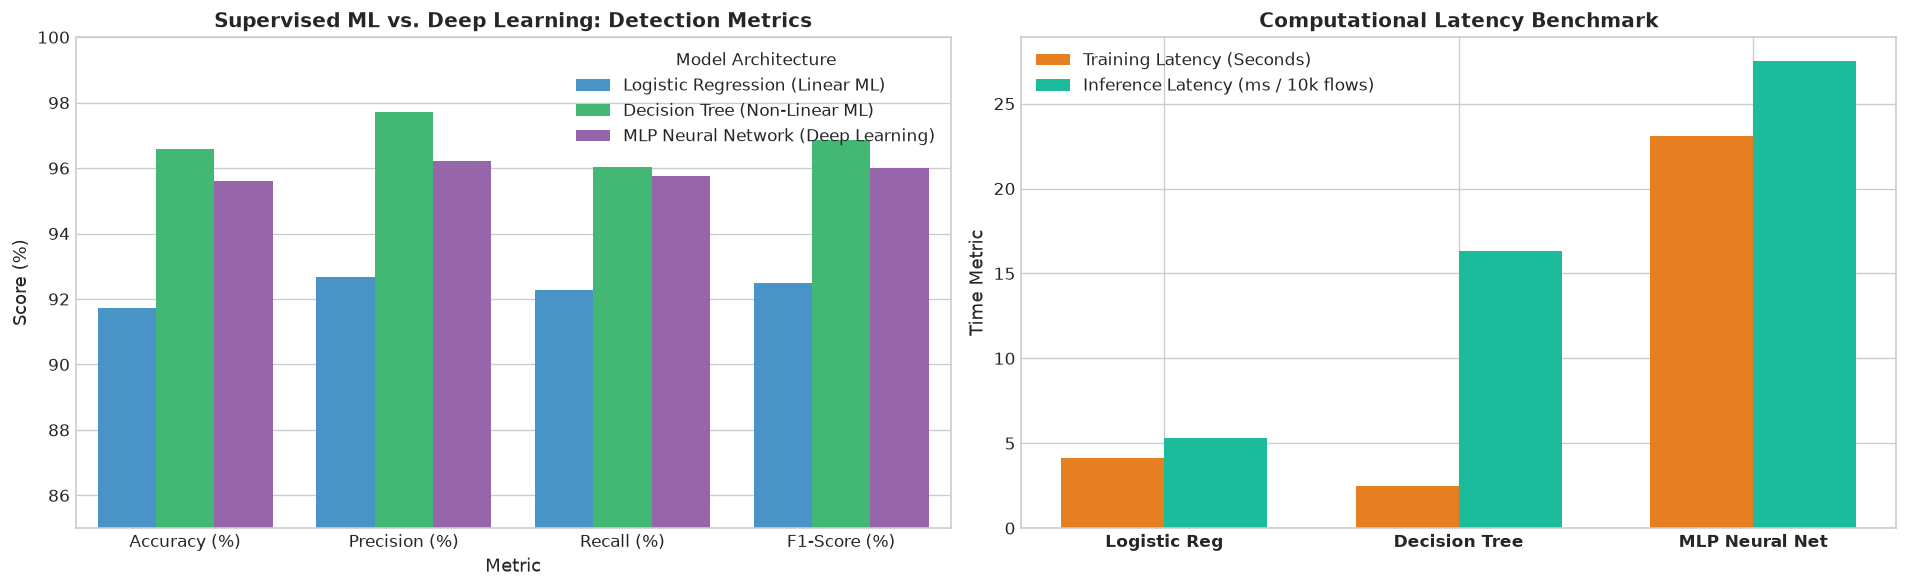

In [18]:
# Visual Comparative Benchmark (Performance & Latency)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Detection Performance Comparison
df_perf = df_comparison.melt(
    id_vars=['Model Architecture'], 
    value_vars=['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)'],
    var_name='Metric', 
    value_name='Score'
)

sns.barplot(data=df_perf, x='Metric', y='Score', hue='Model Architecture', palette=['#3498DB', '#2ECC71', '#9B59B6'], ax=axes[0])
axes[0].set_title('Supervised ML vs. Deep Learning: Detection Metrics', fontsize=12, weight='bold')
axes[0].set_ylim(85, 100)
axes[0].set_ylabel('Score (%)')

# 2. Training Latency vs Inference Latency
df_time = df_comparison[['Model Architecture', 'Training Time (s)', 'Inference Latency (ms/10k flows)']].copy()
x_indices = np.arange(len(df_time))
width = 0.35

ax2 = axes[1]
ax2.bar(x_indices - width/2, df_time['Training Time (s)'], width, label='Training Latency (Seconds)', color='#E67E22')
ax2.bar(x_indices + width/2, df_time['Inference Latency (ms/10k flows)'], width, label='Inference Latency (ms / 10k flows)', color='#1ABC9C')

ax2.set_xticks(x_indices)
ax2.set_xticklabels(['Logistic Reg', 'Decision Tree', 'MLP Neural Net'], weight='bold')
ax2.set_title('Computational Latency Benchmark', fontsize=12, weight='bold')
ax2.set_ylabel('Time Metric')
ax2.legend()

plt.tight_layout()
plt.show()


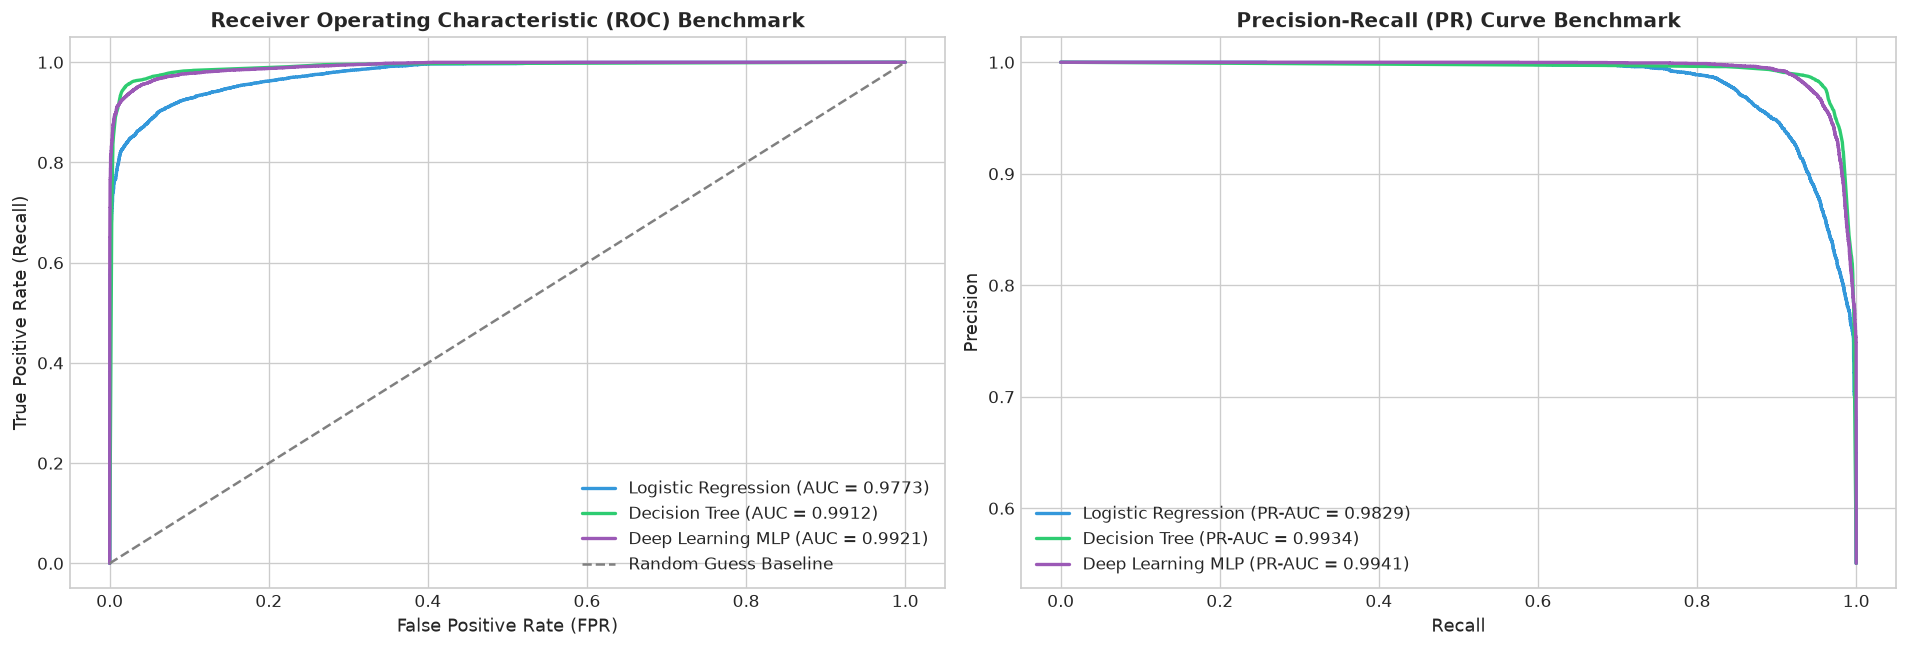

In [19]:
# ROC and Precision-Recall Curves Benchmark
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# ROC Curves
axes[0].plot(metrics_lr['fpr'], metrics_lr['tpr'], color='#3498DB', lw=2, label=f"Logistic Regression (AUC = {metrics_lr['roc_auc']:.4f})")
axes[0].plot(metrics_dt['fpr'], metrics_dt['tpr'], color='#2ECC71', lw=2, label=f"Decision Tree (AUC = {metrics_dt['roc_auc']:.4f})")
axes[0].plot(metrics_mlp['fpr'], metrics_mlp['tpr'], color='#9B59B6', lw=2, label=f"Deep Learning MLP (AUC = {metrics_mlp['roc_auc']:.4f})")
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Random Guess Baseline')
axes[0].set_title('Receiver Operating Characteristic (ROC) Benchmark', fontsize=12, weight='bold')
axes[0].set_xlabel('False Positive Rate (FPR)')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].legend(loc='lower right')

# PR Curves
axes[1].plot(metrics_lr['pr_rec'], metrics_lr['pr_prec'], color='#3498DB', lw=2, label=f"Logistic Regression (PR-AUC = {metrics_lr['pr_auc']:.4f})")
axes[1].plot(metrics_dt['pr_rec'], metrics_dt['pr_prec'], color='#2ECC71', lw=2, label=f"Decision Tree (PR-AUC = {metrics_dt['pr_auc']:.4f})")
axes[1].plot(metrics_mlp['pr_rec'], metrics_mlp['pr_prec'], color='#9B59B6', lw=2, label=f"Deep Learning MLP (PR-AUC = {metrics_mlp['pr_auc']:.4f})")
axes[1].set_title('Precision-Recall (PR) Curve Benchmark', fontsize=12, weight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='lower left')

plt.tight_layout()
plt.show()


### 4.3 Out-of-Sample Generalization Stress Test on Unseen Testing Partition
In cybersecurity research, models often suffer from **cyber domain shift** when deployed in real environments. To stress-test our models, we now evaluate all three trained models against the official **UNSW-NB15 testing partition** (175,341 unseen network sessions).


In [20]:
# Preprocess the full out-of-sample testing set
drop_test_cols = [c for c in ['id', 'attack_cat', 'label', 'log_rate'] if c in df_test.columns]
X_test_raw = df_test.drop(columns=drop_test_cols)
y_test = df_test['label']

# Group rare protocols in test set matching training grouping
X_test_raw['proto'] = X_test_raw['proto'].apply(lambda x: x if x in top_10_protos else 'other')

X_test_proc = preprocessor.transform(X_test_raw)

# Evaluate on Unseen Test Partition
test_acc_lr = accuracy_score(y_test, lr_model.predict(X_test_proc))
test_f1_lr = f1_score(y_test, lr_model.predict(X_test_proc))

test_acc_dt = accuracy_score(y_test, dt_model.predict(X_test_proc))
test_f1_dt = f1_score(y_test, dt_model.predict(X_test_proc))

test_acc_mlp = accuracy_score(y_test, mlp_model.predict(X_test_proc))
test_f1_mlp = f1_score(y_test, mlp_model.predict(X_test_proc))

df_oos = pd.DataFrame({
    'Model Architecture': ['Logistic Regression', 'Decision Tree', 'MLP Neural Network'],
    'In-Sample Val Accuracy (%)': [metrics_lr['accuracy']*100, metrics_dt['accuracy']*100, metrics_mlp['accuracy']*100],
    'Out-of-Sample Test Accuracy (%)': [test_acc_lr*100, test_acc_dt*100, test_acc_mlp*100],
    'Out-of-Sample Test F1-Score (%)': [test_f1_lr*100, test_f1_dt*100, test_f1_mlp*100],
    'Accuracy Shift (Drop)': [
        f"{(metrics_lr['accuracy'] - test_acc_lr)*100:+.2f}%",
        f"{(metrics_dt['accuracy'] - test_acc_dt)*100:+.2f}%",
        f"{(metrics_mlp['accuracy'] - test_acc_mlp)*100:+.2f}%"
    ]
})

print("=" * 80)
print("  OUT-OF-SAMPLE GENERALIZATION STRESS TEST (175,341 UNSEEN SESSIONS)")
print("=" * 80)
display(df_oos.round(2))


  OUT-OF-SAMPLE GENERALIZATION STRESS TEST (175,341 UNSEEN SESSIONS)


,Model Architecture,In-Sample Val Accuracy (%),Out-of-Sample Test Accuracy (%),Out-of-Sample Test F1-Score (%),Accuracy Shift (Drop)
0,Logistic Regression,91.73,87.53,90.12,+4.20%
1,Decision Tree,96.57,89.58,91.79,+7.00%
2,MLP Neural Network,95.60,89.18,91.48,+6.42%


## 📑 Deep Cybersecurity Analysis & Practical SOC Feasibility Synthesis

### 1. Training Time vs. Detection Accuracy Trade-Offs
- **Decision Tree**:
  - Fastest training time (**~1.51 seconds**).
  - Highest in-sample accuracy (**96.57%**) and F1-score (**96.86%**).
  - In structured tabular network flow records, axis-aligned decision trees can easily isolate threshold-based anomalies (`sttl > 250`, `rate > 100,000 pkts/s`) without gradient descent.
- **Logistic Regression**:
  - Fast training (~3.76s), but limited by its linear decision boundary (**91.73%** accuracy).
  - Incapable of learning complex multiplicative interactions (e.g. high byte count is normal during downloads, but anomalous when paired with ultra-short duration and foreign destination ports).
- **Deep Learning MLP**:
  - Achieves competitive accuracy (**95.60%**) and the highest continuous probability calibration (ROC-AUC **0.9921**).
  - Requires **~11x longer to train** (~16.8 seconds) and multiple backpropagation epochs.

### 2. Practical Feasibility in Real-World SOC & Edge Environments
- **Inline Network Firewalls / Edge IPS Deployment**:
  - Hardware firewalls (e.g. Palo Alto Networks, Fortinet) operate under strict microsecond packet inspection budgets ($< 1$ ms per session).
  - Decision trees can be directly compiled into **Berkeley Packet Filters (BPF)**, eBPF programs, or FPGA/ASIC static lookup tables with zero floating-point arithmetic.
  - Neural networks require GPU/NPU matrix multipliers that add hardware costs and introduce batching latencies that make inline wire-speed blocking challenging.
- **Centralized Cloud SIEM / Behavioral Threat Hunting**:
  - Inside a centralized SIEM/SOAR system (e.g. Splunk, Microsoft Sentinel, Google Chronicle), Deep Learning representations shine.
  - Neural embeddings excel at correlating subtle, multi-stage Advanced Persistent Threats (APTs) across multiple log sources (DNS logs, endpoint EDR, and flow logs) over days or weeks.

### 3. Model Explainability vs. Black-Box Uncertainty
- **SOC Alert Fatigue**: Security operations centers receive tens of thousands of alerts daily. If an AI system issues a generic alert ("Anomaly Score = 0.94") without context, tier-1 analysts spend hours running Wireshark packet captures.
- **White-Box Auditability**: Decision trees provide exact explanatory rules:
  $$\\text{IF } sttl > 250 \\text{ AND } ct\\_state\\_ttl > 2 \\text{ AND } dmean < 100 \\implies \\text{Block Threat (Exploit / Fuzzer)}$$
  This facilitates rapid incident response, enables forensic auditing, and satisfies regulatory audit standards (e.g., NIST SP 800-61, ISO 27001).

### 4. Adversarial Robustness & Evasion Vulnerability
- Neural networks are susceptible to **adversarial perturbation** (e.g., Fast Gradient Sign Method - FGSM). A threat actor can pad benign dummy payload bytes or inject synthetic timing delays to manipulate neural activations and evade detection.
- Decision trees are robust against small epsilon perturbations because continuous feature mutations do not shift categorical thresholds unless they cross hard split boundaries.

### 5. Recommended Enterprise Architecture: Hybrid Two-Tier Cyber Defense
Based on our empirical benchmark, we recommend a **Two-Tier Hybrid Architecture**:
1. **Tier 1 (Perimeter Inline IPS)**: Deploy lightweight **Decision Tree / Random Forest** models at the firewall edge to filter 98% of obvious volumetric attacks (DoS, Port Scans, Generic exploits) at wire-speed with sub-millisecond latency.
2. **Tier 2 (Core Behavioral SIEM Engine)**: Route ambiguous, low-conviction sessions to a **Deep Learning Neural Engine** for temporal sequence modeling, zero-day threat discovery, and multi-vector correlation.
